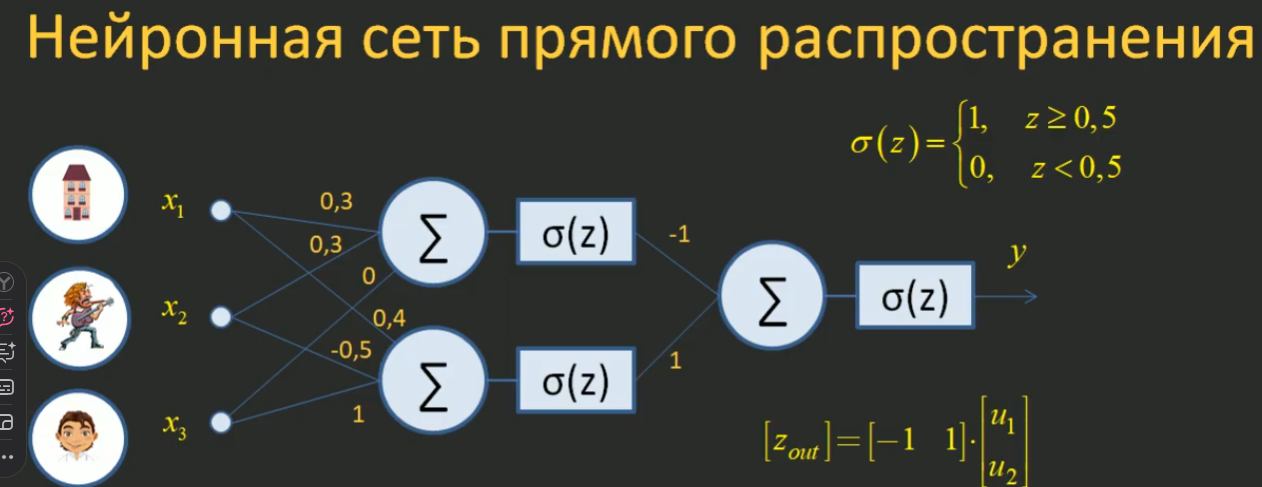

In [1]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
def act(x):
    return 0 if x < 0.5 else 1

погуглить в чем разница флоат 32 от флоат 64 и тд

In [3]:
def go(house, rock, attr):
    X = torch.tensor([house, rock, attr], dtype=torch.float32, device=device)
    Wh = torch.tensor([(0.3, 0.3, 0), (0.4, -0.5, 1)], device=device)
    Wout = torch.tensor([-1,1], dtype = torch.float32, device=device)
    
    Zh = torch.mv(Wh, X) # вычисляем сумму на первом слое (перемножаем входящие значения в виде вектора на матрицу весов)
    print(f'Значения сумм на нейронах первого слоя: {Zh}')
    
    Uh = torch.tensor([act(x) for x in Zh], dtype=torch.float32, device=device)
    print(f'Значения на выходах нейронов: {Uh}')
    
    Zout = torch.dot(Wout, Uh) # произведение двух векторов для получения одного числа (скалярное)
    Y = act(Zout)
    print(f'Выходное значение НС: {Y}')
    
    return Y
    

In [6]:
house = 1
rock = 0
attr = 1

res = go(house, rock, attr)
if res == 1:
    print('нравится')
else:
    print('не нравится')

Значения сумм на нейронах первого слоя: tensor([0.3000, 1.4000], device='cuda:0')
Значения на выходах нейронов: tensor([0., 1.], device='cuda:0')
Выходное значение НС: 1
нравится


Если влом  в каждом тензоре писать устройство, то можно поставить по устройство умолчанию:

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
torch.set_default_device(device)

Тогда если у вас есть куда, то она везде подключится без лишних телодвижений